*Matplotlip*

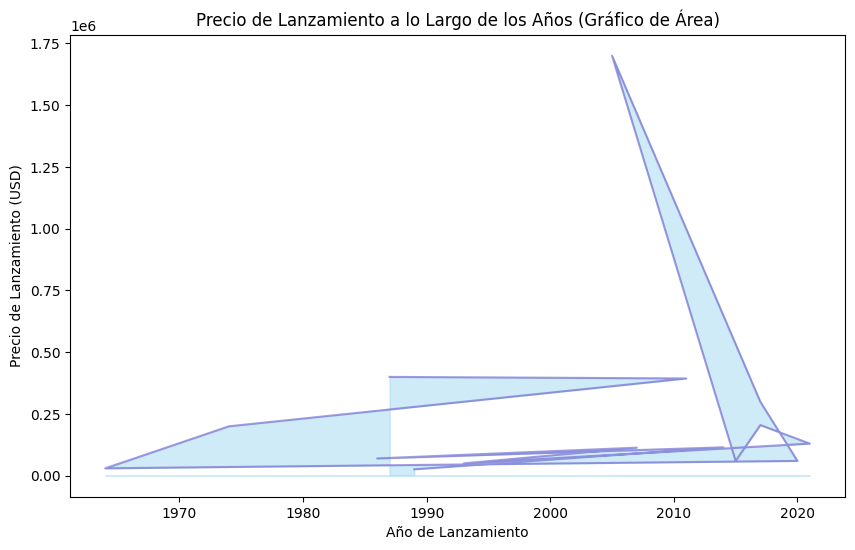

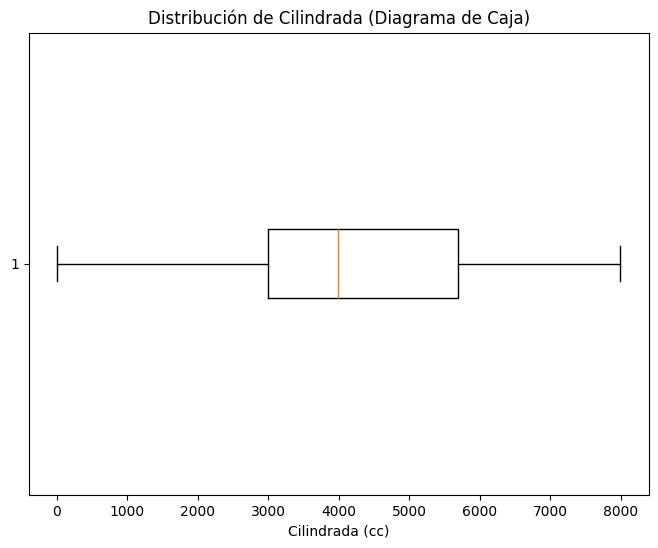

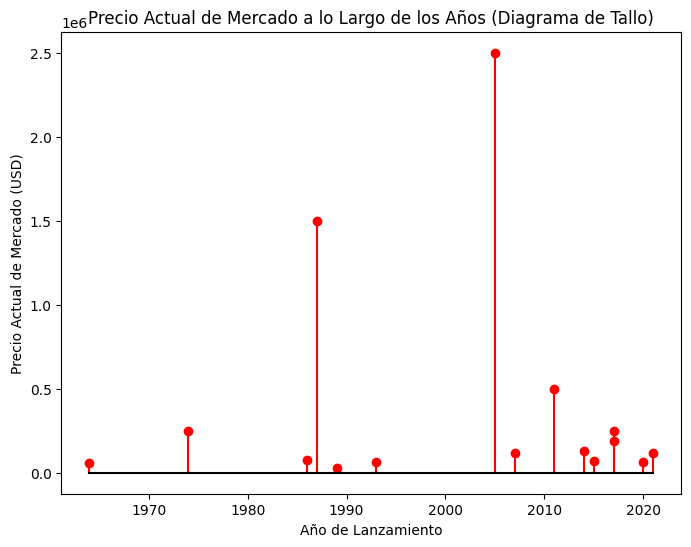

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Cargar el archivo para inspección
file_path = 'C:/Users/Zephyrus/Downloads/car_models(1).csv'
datos_autos = pd.read_csv(file_path)

# Mostrar las primeras filas y los nombres de las columnas
datos_autos.head(), datos_autos.columns

# Gráfico de área
plt.figure(figsize=(10, 6))
plt.fill_between(datos_autos['Año de Lanzamiento'], datos_autos['Precio de Lanzamiento (USD)'], color="skyblue", alpha=0.4)
plt.plot(datos_autos['Año de Lanzamiento'], datos_autos['Precio de Lanzamiento (USD)'], color="Slateblue", alpha=0.6)
plt.title("Precio de Lanzamiento a lo Largo de los Años (Gráfico de Área)")
plt.xlabel("Año de Lanzamiento")
plt.ylabel("Precio de Lanzamiento (USD)")
plt.show()

# Diagrama de caja
plt.figure(figsize=(8, 6))
plt.boxplot(datos_autos['Cilindrada (cc)'], vert=False)
plt.title("Distribución de Cilindrada (Diagrama de Caja)")
plt.xlabel("Cilindrada (cc)")
plt.show()

# Diagrama de tallo
plt.figure(figsize=(8, 6))
plt.stem(datos_autos['Año de Lanzamiento'], datos_autos['Precio Actual de Mercado (USD)'], linefmt='r-', markerfmt='ro', basefmt="k-")
plt.title("Precio Actual de Mercado a lo Largo de los Años (Diagrama de Tallo)")
plt.xlabel("Año de Lanzamiento")
plt.ylabel("Precio Actual de Mercado (USD)")
plt.show()

*Seaborn*

C:\Users\Zephyrus\AppData\Local\Temp\ipykernel_28668\3338813962.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Año de Lanzamiento', y='Cilindrada (cc)', data=datos_autos, palette="muted")


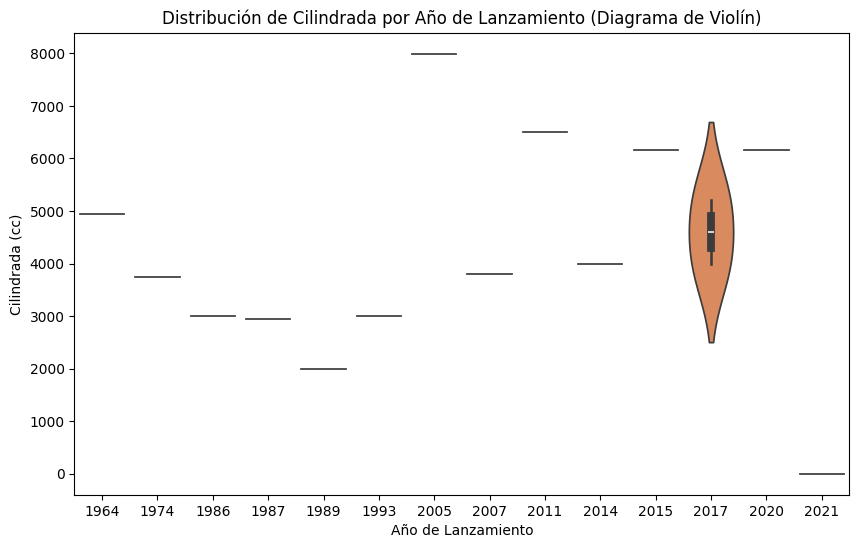

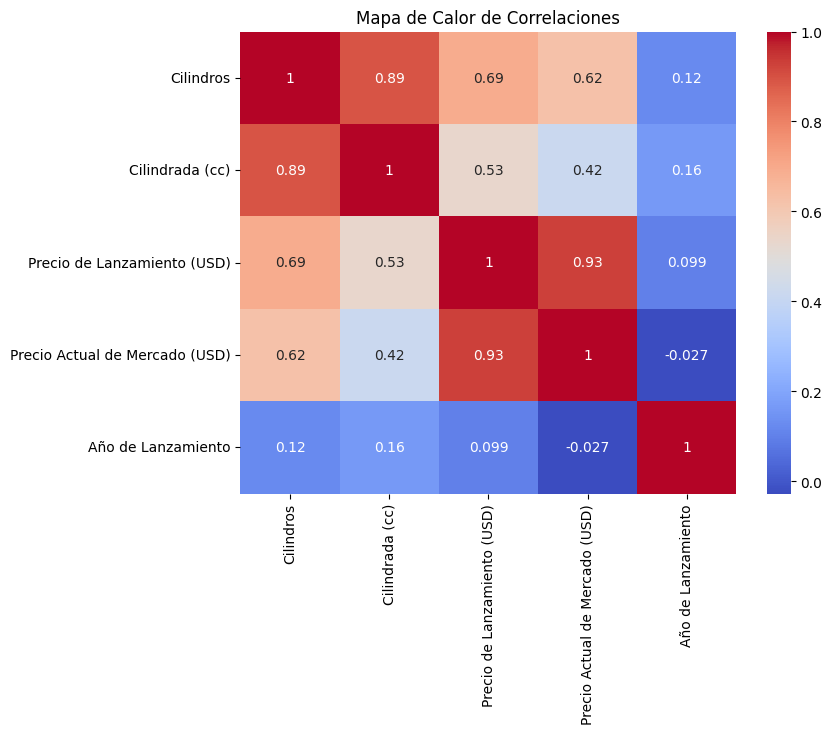

C:\Users\Zephyrus\AppData\Local\Temp\ipykernel_28668\3338813962.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Año de Lanzamiento', y='Precio Actual de Mercado (USD)', data=datos_autos, jitter=0.3, palette="Set2")


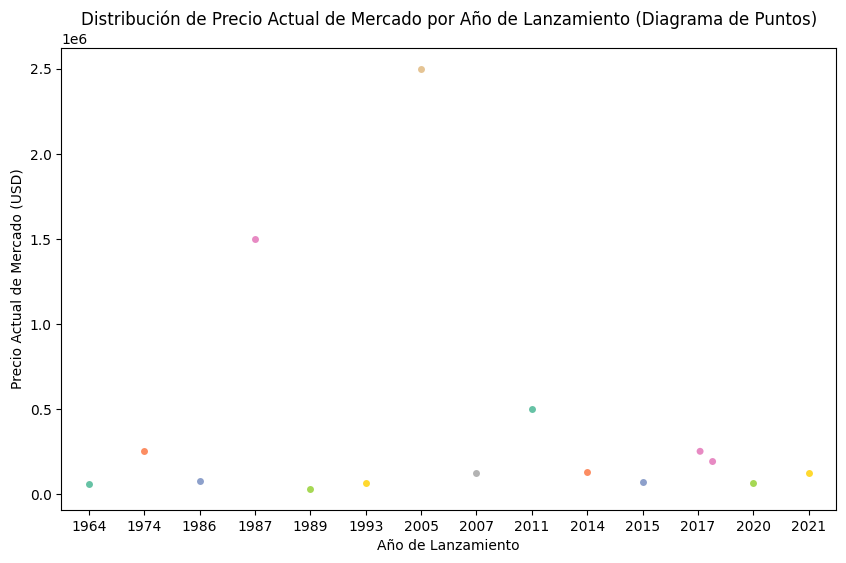

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Diagrama de violín
plt.figure(figsize=(10, 6))
sns.violinplot(x='Año de Lanzamiento', y='Cilindrada (cc)', data=datos_autos)
plt.title("Distribución de Cilindrada por Año de Lanzamiento (Diagrama de Violín)")
plt.show()

# Mapa de calor (solo con columnas numéricas)
matriz_correlacion = datos_autos.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm")
plt.title("Mapa de Calor de Correlaciones")
plt.show()

# Diagrama de puntos
plt.figure(figsize=(10, 6))
sns.stripplot(x='Año de Lanzamiento', y='Precio Actual de Mercado (USD)', data=datos_autos, jitter=0.3, palette="Set2")
plt.title("Distribución de Precio Actual de Mercado por Año de Lanzamiento (Diagrama de Puntos)")
plt.show()

*Plotly*

In [3]:
import plotly.express as px
import plotly.graph_objects as go

# Gráfico de superficie 3D
fig = go.Figure(data=[go.Surface(z=np.random.rand(10, 10))])
fig.update_layout(title="Gráfico de Superficie 3D Aleatorio", autosize=False, width=700, height=700)
fig.show()

# Gráfico de embudo
fig = px.funnel(datos_autos, x='Cilindrada (cc)', y='Modelo')
fig.update_layout(title="Gráfico de Embudo de Modelos de Autos por Cilindrada")
fig.show()

# Gráfico sunburst
fig = px.sunburst(datos_autos, path=['Marca', 'Modelo'], values='Precio Actual de Mercado (USD)')
fig.update_layout(title="Gráfico Sunburst de Precio Actual de Mercado por Marca y Modelo")
fig.show()

*Bokeh*

In [4]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from math import pi

output_notebook()

# Gráfico hexagonal
p = figure(title="Gráfico Hexagonal de Precio de Lanzamiento vs Cilindrada", match_aspect=True, tools="wheel_zoom", background_fill_color='#440154')
r, bins = p.hexbin(datos_autos['Precio de Lanzamiento (USD)'], datos_autos['Cilindrada (cc)'], size=5, hover_color="pink", hover_alpha=0.8)
p.grid.visible = False
show(p)

# Gráfico de área
años = datos_autos['Año de Lanzamiento'].unique()
precio_promedio_año = datos_autos.groupby('Año de Lanzamiento')['Precio Actual de Mercado (USD)'].mean().reset_index()
p = figure(title="Precio Promedio Actual de Autos por Año", x_axis_label='Año de Lanzamiento', y_axis_label='Precio Promedio Actual (USD)')
p.varea(x=precio_promedio_año['Año de Lanzamiento'], y1=precio_promedio_año['Precio Actual de Mercado (USD)'])
show(p)

# Gráfico de dona (aproximado usando la forma de una dona)
p = figure(title="Gráfico de Dona de Cilindrada", match_aspect=True, tools="hover")
conteo_cilindrada = datos_autos['Cilindrada (cc)'].value_counts()
ángulos = np.cumsum(conteo_cilindrada) / conteo_cilindrada.sum() * 2 * pi
p.wedge(x=0, y=1, radius=0.4, start_angle=ángulos[:-1], end_angle=ángulos[1:], color="navy", alpha=0.8)
show(p)

Loading BokehJS ...